In [54]:
import stim
import numpy as np

from spiderwarp.csscode import CSSCode
from spiderwarp.utils import load_state_prep_circuit
from spiderwarp.stim_utils import steane_se_from_stim_state_prep, get_num_measurements, perfect_state_from_code, \
    get_circuit_depth
from spiderwarp.path_cover import CoveredZXGraph
from spiderwarp.path_cover_metrics import metric_spacetime_volume_exact, metric_hardware_qubits_exact, metric_num_paths, \
    metric_depth, LexicographicCost, metric_depth_exact
from spiderwarp.qubit_reuse import build_circuit_dag, apply_logical_qubit_merge_and_compress, dag_to_circuit, \
    inject_qubit_reuse, VolumeOptimizingReuseStrategy, AggressiveDepthAwareStrategy, NoReuseStrategy, \
    PureAggressiveStrategy


%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
code_dir, code_name, circ_dir, circ_path = "MQT", "17_1_5", "SAT", "cc_4_8_8_d5/zero_ft_heuristic_opt"
# code_dir, code_name, circ_dir, circ_path = "MQT", "17_1_5", "misc", "zero_17_1_5"
code_dir, code_name, circ_dir, circ_path = "MQT", "17_1_5", "boldi", "17_1_5"
# code_dir, code_name, circ_dir, circ_path = "MQT", "15_7_3", "boldi", "15_7_3"
# code_dir, code_name, circ_dir, circ_path = "MQT", "15_1_3", "boldi", "15_1_3"
# code_dir, code_name, circ_dir, circ_path = "MQT", "20_2_6", "boldi", "20_2_6"
# code_dir, code_name, circ_dir, circ_path = "MQT", "12_2_4", "boldi", "12_2_4"
# code_dir, code_name, circ_dir, circ_path = "MQT", "15_7_3", "SAT", "hamming/zero_ft_opt_opt"
# code_dir, code_name, circ_dir, circ_path = "MQT", "7_1_3", "SAT", "steane/zero_ft_opt_opt"

code = CSSCode.load_code(code_dir, code_name)

perfect_state = perfect_state_from_code(code, "X")

test = perfect_state.copy()
test.append("MX", range(code.n))
print(test.compile_sampler().sample(10)[:,-code.n:] @ code.H_x.T % 2)

[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


Depth: 33
Number of ancilla qubits necessary: 23


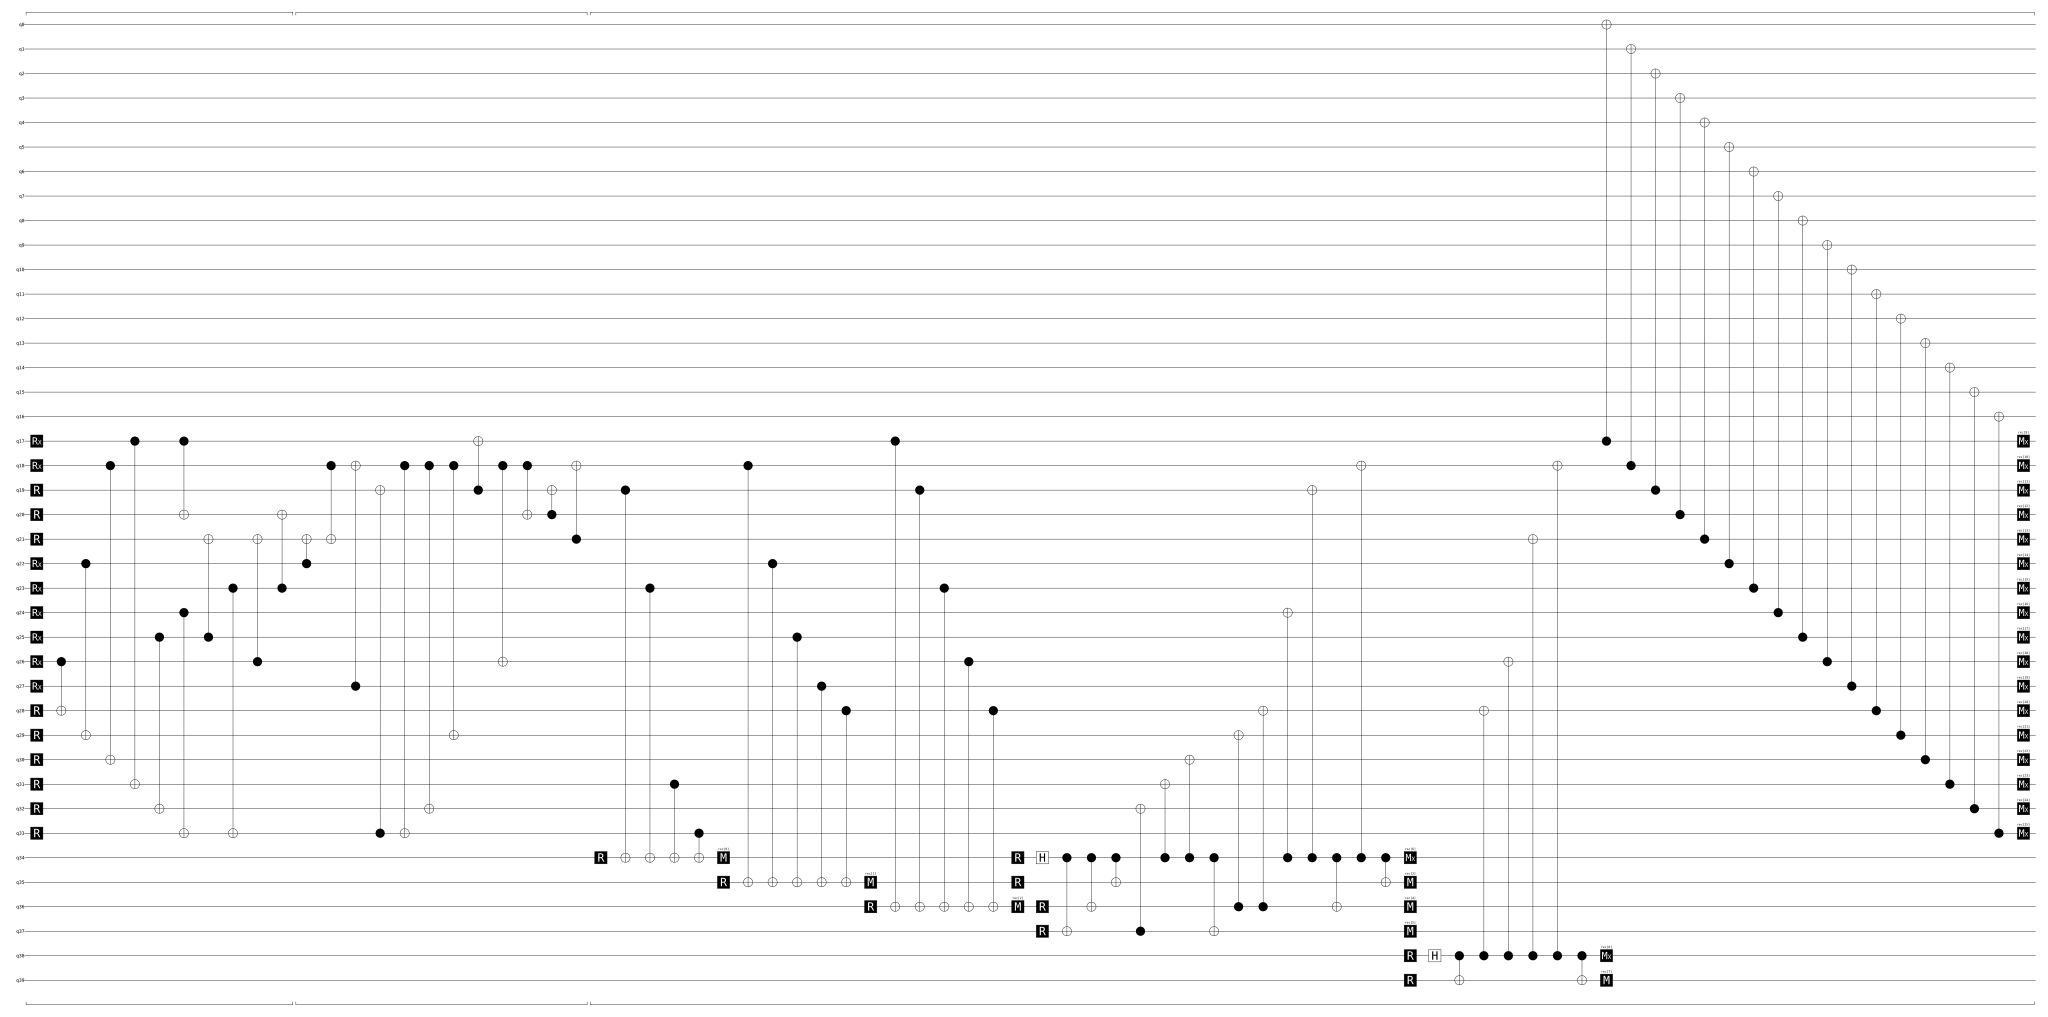

In [56]:
circuit = load_state_prep_circuit(circ_dir, circ_path)
se = steane_se_from_stim_state_prep(circuit, se_basis="Z", n=code.n)

print("Depth:", get_circuit_depth(se))
print("Number of ancilla qubits necessary:", se.num_qubits - code.n)
se.diagram('timeline-svg')

In [57]:
samples = (perfect_state + se).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]
print(samples.shape)
print(samples[:,:-code.n].astype(int))
print(samples[:,-code.n:] @ code.H_z.T % 2)

(10, 26)
[[0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0]]
[[0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]


In [58]:
covered = CoveredZXGraph.from_stim(se)
covered.basic_FE_rewrites()


optimised = covered.greedy_best_first_boundary_bends(
    cost_func=metric_hardware_qubits_exact(VolumeOptimizingReuseStrategy),
    # cost_func=metric_spacetime_volume_exact(VolumeOptimizingReuseStrategy),
    # cost_func=metric_hardware_qubits_exact(AggressiveDepthAwareStrategy),
    # cost_func=metric_hardware_qubits_exact(NoReuseStrategy),
)
# optimised.optimize_path_extremities()
new_circuit, measurement_map = optimised.extract_circuit_with_measurement_map()

print("Depth:", get_circuit_depth(new_circuit))
print("Number of ancilla qubits necessary:", new_circuit.num_qubits - code.n)
new_circuit.diagram('timeline-svg')

ValueError: No solution found: cycle detected in causal-flow constraints.

In [46]:
samples = (perfect_state + new_circuit).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in measurement_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print(samples.shape, num_measurements - len(flag_indices))

print("Flags:", flags, sep="\n", end="\n\n")

print("measurement_map:", measurement_map)
syndrome_indices = {k: v - (num_measurements - code.n) for k, v in measurement_map.items() if v >= num_measurements - code.n}
print("syndrome_indices:", syndrome_indices)
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

(10, 9) 15
Flags:
[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]]

measurement_map: {0: 0, 1: 11, 2: 16, 3: 15, 4: 13, 5: 14, 6: 4, 7: 1, 8: 10}
syndrome_indices: {1: 9, 2: 14, 3: 13, 4: 11, 5: 12, 6: 2, 8: 8}
Syndromes:
[[0 0 0 0 1 1 0 1 0 1]
 [0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 1 1 1 1]
 [0 0 0 0 1 1 0 1 0 1]
 [0 0 0 0 1 1 0 0 0 0]
 [0 0 0 0 1 1 1 0 1 0]
 [0 0 0 0 0 0 1 0 1 0]
 [0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 1 1 0 1 0 1]
 [0 0 0 0 1 1 0 1 0 1]]


Depth: 22
Number of ancilla qubits necessary: 8
Mapping of new measurements to old measurements: {0: 0, 1: 11, 2: 16, 3: 15, 4: 14, 5: 13, 6: 4, 7: 1, 8: 10}


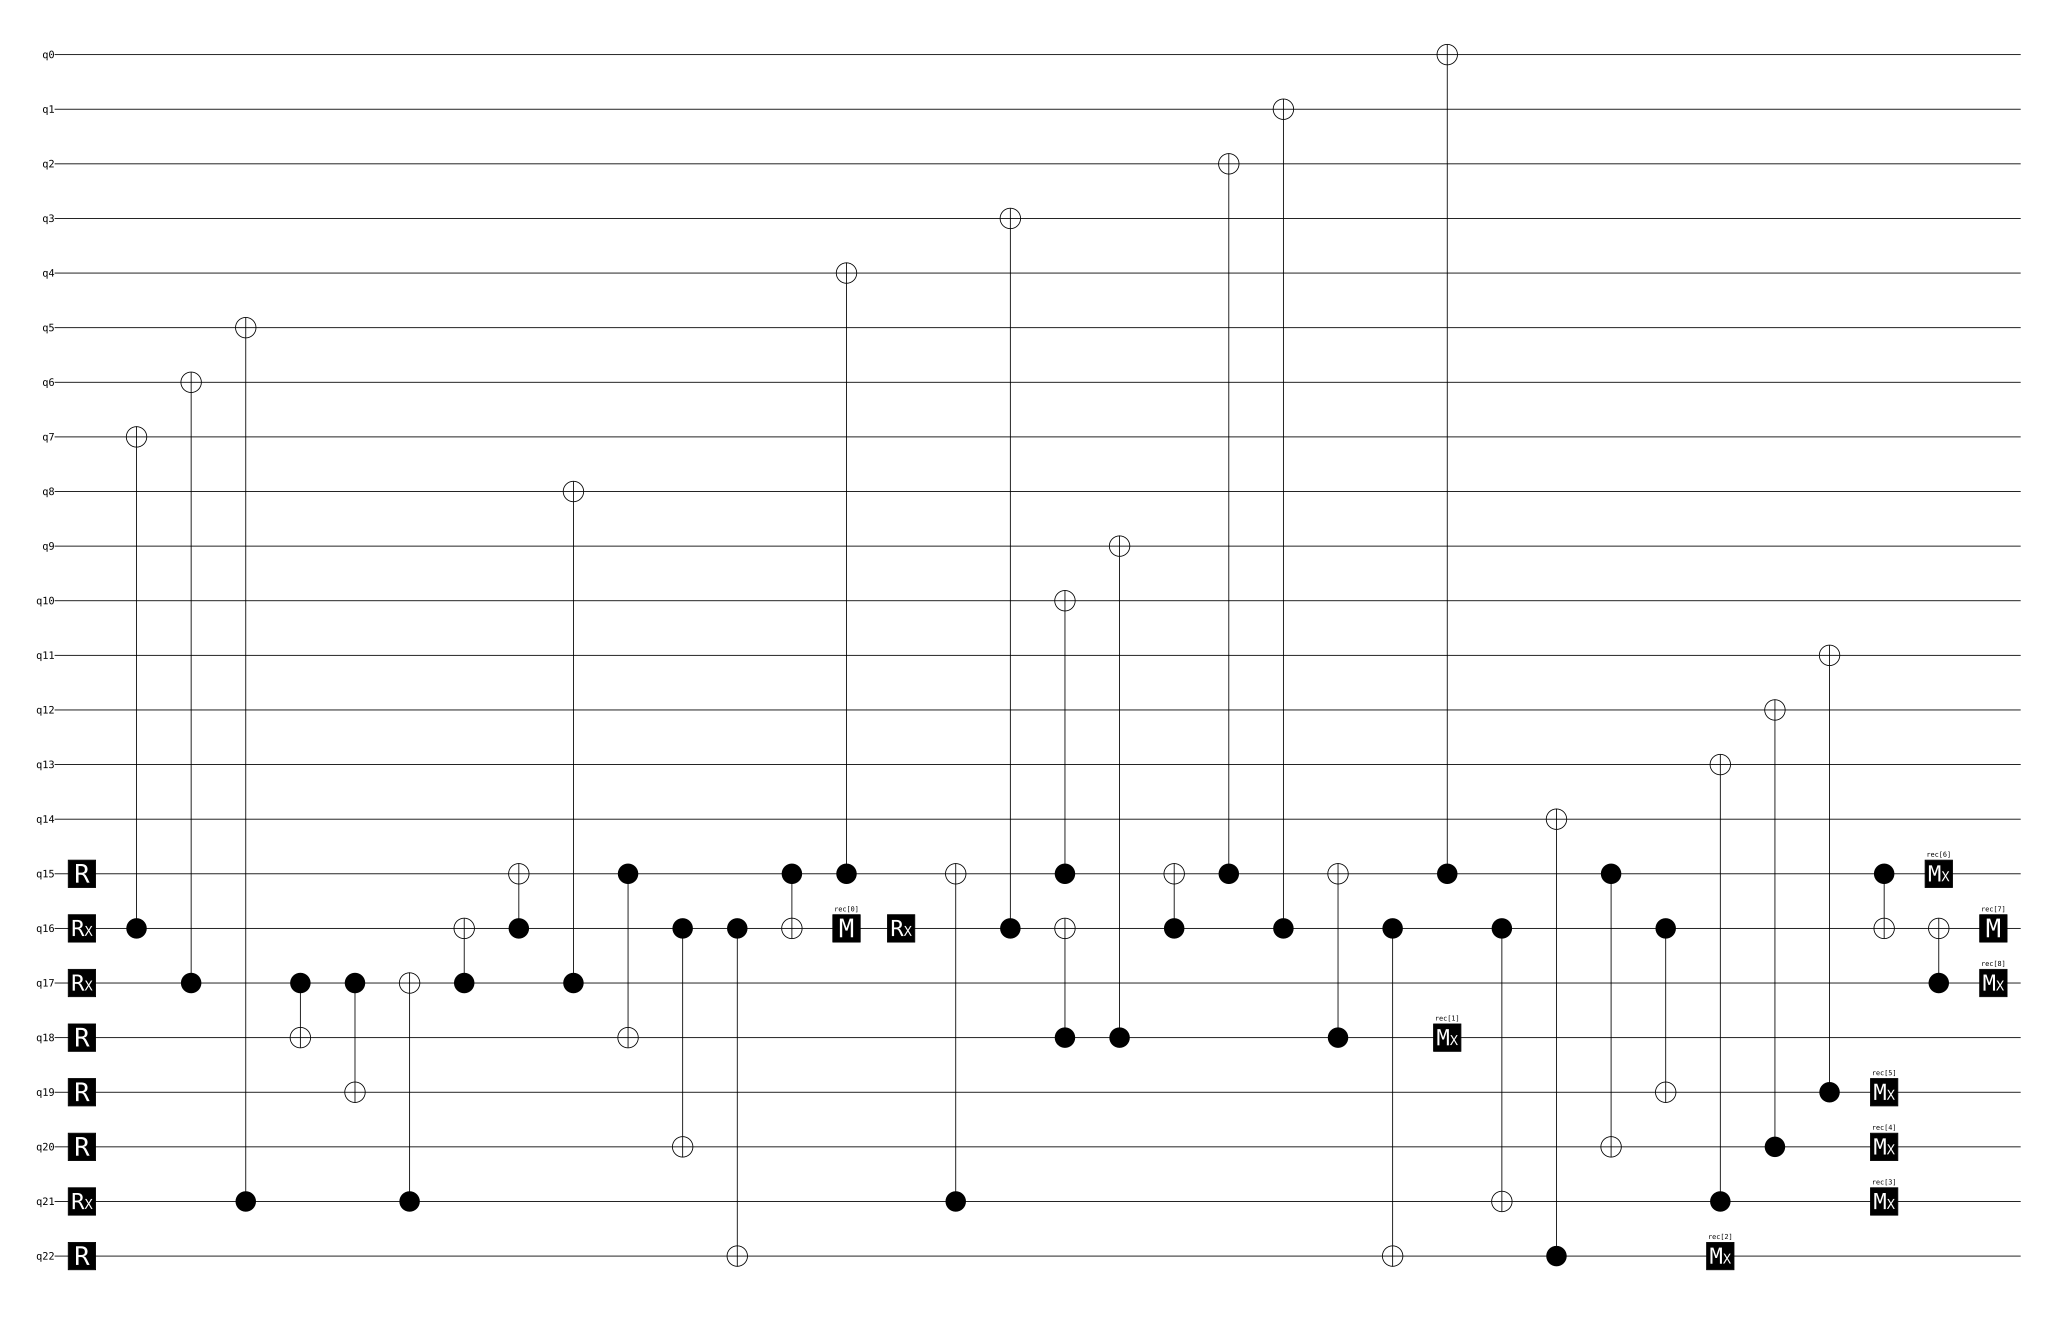

In [48]:
dag = build_circuit_dag(optimised)

mod_dag, logical_to_physical, total_hw = inject_qubit_reuse(dag, code.n, VolumeOptimizingReuseStrategy())
compressed_dag = apply_logical_qubit_merge_and_compress(mod_dag, code.n)
final_circ, final_meas_map = dag_to_circuit(compressed_dag)

print("Depth:", get_circuit_depth(final_circ))
print("Number of ancilla qubits necessary:", final_circ.num_qubits - code.n)
print("Mapping of new measurements to old measurements:", final_meas_map)
final_circ.diagram('timeline-svg')

In [22]:
samples = (perfect_state + final_circ).compile_sampler().sample(10)
samples = samples[:,code.H_z.shape[0]:]

num_measurements = get_num_measurements(se)
flag_indices = [k for k, v in final_meas_map.items() if v < num_measurements - code.n]
flags = samples[:,flag_indices].astype(int)

print("Flags:", flags, sep="\n", end="\n\n")

syndrome_indices = {k: v - (num_measurements - code.n) for k, v in final_meas_map.items() if v >= num_measurements - code.n}
effective_H = code.H_z[:,list(syndrome_indices.values())]
raw_syndrome_measurements = samples[:,list(syndrome_indices.keys())]
syndromes = raw_syndrome_measurements @ effective_H.T % 2

print("Syndromes:", syndromes, sep="\n")

Flags:
[[0]
 [1]
 [0]
 [1]
 [1]
 [0]
 [1]
 [1]
 [1]
 [0]]

Syndromes:
[[0 0 0 0]
 [1 0 1 1]
 [0 0 0 0]
 [1 0 1 1]
 [1 0 1 1]
 [0 0 0 0]
 [1 0 1 1]
 [1 0 1 1]
 [1 0 1 1]
 [0 0 0 0]]
